# Detecção de Anomalias em Gastos Municipais do Paraná

| N | Ação |
|---|---|
| 1 | Imports |
| 2 | Carregar datasets |
| 3 | Limpar declarações ruins |
| 4 | Features |
| 5 | Normalizar |
| 6 | Isolation Forest + LOF |
| 7 | Resultados |
| 8 | Exportar |



## 1 — Imports



In [ ]:
import warnings, re, hashlib
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer

DATA_DIR    = Path('data')
EXPORTS_DIR = Path('exports')
EXPORTS_DIR.mkdir(exist_ok=True)

ANOS = [2020, 2021, 2022, 2023, 2024, 2025]
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ISSO VEIO DEFINIDO DO DATASET, É DISTRIBUÍDO ASSIM POR PADRÃO

FUNCOES = {
    '01':'legislativa','02':'judiciaria','03':'essencial_justica','04':'administracao',
    '05':'defesa_nacional','06':'seguranca_publica','07':'relacoes_exteriores',
    '08':'assistencia_social','09':'previdencia_social','10':'saude','11':'trabalho',
    '12':'educacao','13':'cultura','14':'direitos_cidadania','15':'urbanismo',
    '16':'habitacao','17':'saneamento','18':'gestao_ambiental','19':'ciencia_tecnologia',
    '20':'agricultura','21':'organizacao_agraria','22':'industria','23':'comercio_servicos',
    '24':'comunicacoes','25':'energia','26':'transporte','27':'desporto_lazer',
    '28':'encargos_especiais','99':'reserva_contingencia',
}
COL_FUNCOES = list(FUNCOES.values())

plt.rcParams['figure.dpi']  = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size']   = 10

print('Setup ok.')

# CIDADE APARECE EM TODAS SEÇÕES DE TRATAMENTO

ANCORA_NOME = 'Porto Rico'
ANCORA_ANO  = 2024


def lupa(dataframe):
    """Retorna a linha (Series) do municipio-ancora no dataframe atual."""
    sel = dataframe[(dataframe['municipio'] == ANCORA_NOME) &
                    (dataframe['ano'] == ANCORA_ANO)]
    if len(sel) == 0:
        return None
    return sel.iloc[0]



Setup ok.


In [ ]:
# Rotulos amigaveis para tornar graficos e impressoes legiveis.

LABELS_FUNCAO = {
    'legislativa':          'Legislativa',
    'judiciaria':           'Judiciaria',
    'essencial_justica':    'Essencial a Justica',
    'administracao':        'Administracao',
    'defesa_nacional':      'Defesa Nacional',
    'seguranca_publica':    'Seguranca Publica',
    'relacoes_exteriores':  'Relacoes Exteriores',
    'assistencia_social':   'Assistencia Social',
    'previdencia_social':   'Previdencia Social',
    'saude':                'Saude',
    'trabalho':             'Trabalho',
    'educacao':             'Educacao',
    'cultura':              'Cultura',
    'direitos_cidadania':   'Direitos da Cidadania',
    'urbanismo':            'Urbanismo',
    'habitacao':            'Habitacao',
    'saneamento':           'Saneamento',
    'gestao_ambiental':     'Gestao Ambiental',
    'ciencia_tecnologia':   'Ciencia e Tecnologia',
    'agricultura':          'Agricultura',
    'organizacao_agraria':  'Organizacao Agraria',
    'industria':            'Industria',
    'comercio_servicos':    'Comercio e Servicos',
    'comunicacoes':         'Comunicacoes',
    'energia':              'Energia',
    'transporte':           'Transporte',
    'desporto_lazer':       'Desporto e Lazer',
    'encargos_especiais':   'Encargos Especiais',
    'reserva_contingencia': 'Reserva de Contingencia',
}

LABELS_SUFIXO = {
    '_pc':   'R$ por habitante',
    '_prop': '% do gasto total',
    '_var':  'variacao ano-a-ano',
    '_dev':  'desvio do cluster',
}

LABELS_CONTEXTO = {
    'log_pop':         'Porte populacional (log)',
    'log_pop_cl':      'Porte populacional (log)',
    'log_total_pc_cl': 'Gasto per capita total (log)',
    'hhi':             'Concentracao do gasto (HHI)',
}


def pretty(feat: str) -> str:
    """Traduz nome tecnico de feature em rotulo legivel."""
    if feat in LABELS_CONTEXTO:
        return LABELS_CONTEXTO[feat]
    for suf, label in LABELS_SUFIXO.items():
        if feat.endswith(suf):
            base = feat[:-len(suf)]
            nome = LABELS_FUNCAO.get(base, base.replace('_', ' ').title())
            return f'{nome} ({label})'
    return LABELS_FUNCAO.get(feat, feat.replace('_', ' ').title())


# Teste rapido

print('Exemplos de rotulos:')
for f in ['saude_pc', 'habitacao_prop', 'educacao_var',
          'saude_dev', 'log_pop', 'hhi']:
    print(f'  {f:25s} -> {pretty(f)}')



Exemplos de rotulos:
  saude_pc                  -> Saude (R$ por habitante)
  habitacao_prop            -> Habitacao (% do gasto total)
  educacao_var              -> Educacao (variacao ano-a-ano)
  saude_dev                 -> Saude (desvio do cluster)
  log_pop                   -> Porte populacional (log)
  hhi                       -> Concentracao do gasto (HHI)


## 2 — Carregamento

In [3]:
RE_TOP = re.compile(r'^\s*(\d{2})\s*-\s*(.+)$')
RE_SUB = re.compile(r'^\s*\d{2}\.\d{3}')

def _parse_valor_br(s):
    return pd.to_numeric(
        s.astype(str).str.strip()
         .str.replace('.', '', regex=False)
         .str.replace(',', '.', regex=False),
        errors='coerce')

def carregar_finbra(path, ano):
    df = None
    for enc in ['latin-1', 'cp1252', 'utf-8-sig', 'utf-8']:
        try:
            df = pd.read_csv(path, sep=';', encoding=enc, skiprows=3,
                             dtype=str, engine='python')
            df.columns = [str(c).strip().lstrip('\ufeff') for c in df.columns]
            if {'Cod.IBGE', 'Conta', 'Valor'}.issubset(set(df.columns)):
                break
        except Exception:
            df = None
    if df is None:
        raise RuntimeError(f'Nao consegui ler {path}')

    df = df[df['Coluna'].astype(str).str.strip() == 'Despesas Empenhadas'].copy()
    df['Conta'] = df['Conta'].astype(str).str.strip()
    df = df[~df['Conta'].str.contains('Exceto', case=False, na=False)]
    df = df[~df['Conta'].str.match(RE_SUB)]
    m = df['Conta'].str.extract(RE_TOP)
    df['cod_funcao'] = m[0]
    df = df[df['cod_funcao'].notna() & df['cod_funcao'].isin(FUNCOES.keys())]
    df['nome_funcao'] = df['cod_funcao'].map(FUNCOES)
    df['Valor'] = _parse_valor_br(df['Valor'])
    df = df.dropna(subset=['Valor'])
    df['Cod.IBGE'] = (df['Cod.IBGE'].astype(str).str.strip()
                       .str.replace('.', '', regex=False))
    df = df[df['Cod.IBGE'].str.fullmatch(r'41\d{5}')]
    df['cod_ibge'] = df['Cod.IBGE'].astype(int)
    df['municipio'] = (df['Instituição'].astype(str).str.strip()
                       .str.replace(r'\s*-\s*PR\s*$', '', regex=True)
                       .str.replace(r'^Prefeitura Municipal de\s+', '', regex=True))
    df['ano'] = ano
    return df[['cod_ibge', 'municipio', 'ano', 'nome_funcao', 'Valor']]


hashes = {}
for ano in ANOS:
    p = DATA_DIR / f'finbra_dca_ie_PR_{ano}.csv'
    if p.exists():
        h = hashlib.md5(p.read_bytes()).hexdigest()
        if h in hashes:
            print(f'  [AVISO] {p.name} e identico a {hashes[h]} — refazer download')
        hashes[h] = p.name

partes = []
for ano in ANOS:
    p = DATA_DIR / f'finbra_dca_ie_PR_{ano}.csv'
    if not p.exists():
        continue
    d = carregar_finbra(p, ano)
    partes.append(d)
    print(f'  {p.name}: {len(d):,} linhas · {d["cod_ibge"].nunique()} municipios')
finbra = pd.concat(partes, ignore_index=True)
print(f'\nTotal: {len(finbra):,} linhas · {finbra["cod_ibge"].nunique()} municipios')



  finbra_dca_ie_PR_2020.csv: 5,965 linhas · 399 municipios
  finbra_dca_ie_PR_2021.csv: 5,975 linhas · 399 municipios
  finbra_dca_ie_PR_2022.csv: 6,120 linhas · 398 municipios
  finbra_dca_ie_PR_2023.csv: 6,163 linhas · 398 municipios
  finbra_dca_ie_PR_2024.csv: 6,173 linhas · 396 municipios
  finbra_dca_ie_PR_2025.csv: 3,757 linhas · 241 municipios

Total: 34,153 linhas · 399 municipios


In [ ]:
def carregar_ibge(path):
    df = None
    for enc in ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252']:
        try:
            tmp = pd.read_csv(path, sep=';', encoding=enc, skiprows=3,
                              dtype=str, engine='python')
            tmp.columns = [str(c).strip().lstrip('\ufeff') for c in tmp.columns]
            if any(re.fullmatch(r'\d{4}', c) for c in tmp.columns):
                df = tmp; break
        except Exception:
            continue
    if df is None:
        raise RuntimeError(f'Nao consegui ler {path}')

    mun = df.columns[0]
    ano_cols = [c for c in df.columns if re.fullmatch(r'\d{4}', c)]
    df = df[[mun] + ano_cols].rename(columns={mun: 'municipio_ibge'})
    df = df.dropna(subset=['municipio_ibge'])
    df = df[df['municipio_ibge'].str.contains(r'\(PR\)$', regex=True)]
    df['municipio_ibge'] = df['municipio_ibge'].str.replace(
        r'\s*\(PR\)\s*$', '', regex=True).str.strip()

    pop = df.melt(id_vars='municipio_ibge', value_vars=ano_cols,
                  var_name='ano', value_name='populacao')
    pop['ano'] = pop['ano'].astype(int)
    pop['populacao'] = pd.to_numeric(
        pop['populacao'].astype(str).str.replace('.', '', regex=False),
        errors='coerce')
    pop = pop.dropna(subset=['populacao'])
    pop['populacao'] = pop['populacao'].astype(int)
    return pop


pop_ibge = carregar_ibge(DATA_DIR / 'populacao_ibge.csv')
print(f'IBGE: {len(pop_ibge):,} linhas · '
      f'{pop_ibge["municipio_ibge"].nunique()} municipios · '
      f'anos: {sorted(pop_ibge["ano"].unique())}')



IBGE: 1,596 linhas · 399 municipios · anos: [np.int64(2020), np.int64(2021), np.int64(2024), np.int64(2025)]


In [5]:
agg = (finbra.groupby(['cod_ibge', 'municipio', 'ano', 'nome_funcao'])['Valor']
             .sum().reset_index())
wide = (agg.pivot_table(index=['cod_ibge', 'municipio', 'ano'],
                        columns='nome_funcao', values='Valor', fill_value=0.0)
          .reset_index())
wide.columns.name = None
for f in COL_FUNCOES:
    if f not in wide.columns:
        wide[f] = 0.0
wide = wide[['cod_ibge', 'municipio', 'ano'] + COL_FUNCOES]
wide['total_despesas'] = wide[COL_FUNCOES].sum(axis=1)

def norm(s):
    return (s.astype(str).str.lower()
             .str.normalize('NFKD').str.encode('ascii', 'ignore').str.decode('ascii')
             .str.strip().str.replace(r'\s+', ' ', regex=True))

wide['_k']     = norm(wide['municipio'])
pop_ibge['_k'] = norm(pop_ibge['municipio_ibge'])
cod_map = wide.groupby('_k')['cod_ibge'].first().to_dict()
pop_ibge['cod_ibge'] = pop_ibge['_k'].map(cod_map)
pop_ibge = pop_ibge.dropna(subset=['cod_ibge']).copy()
pop_ibge['cod_ibge'] = pop_ibge['cod_ibge'].astype(int)

idx = pd.MultiIndex.from_product([pop_ibge['cod_ibge'].unique(), ANOS],
                                  names=['cod_ibge', 'ano'])
pop_full = (pop_ibge[['cod_ibge', 'ano', 'populacao']]
            .set_index(['cod_ibge', 'ano']).reindex(idx).reset_index()
            .sort_values(['cod_ibge', 'ano']))
pop_full['populacao'] = (pop_full.groupby('cod_ibge')['populacao']
                          .transform(lambda s: s.interpolate(method='linear',
                                                             limit_direction='both')))
pop_full['populacao'] = pop_full['populacao'].round().astype('Int64')

raw_df = wide.drop(columns='_k').merge(pop_full, on=['cod_ibge', 'ano'], how='left')
raw_df = raw_df.dropna(subset=['populacao']).copy()
raw_df['populacao'] = raw_df['populacao'].astype(int)

print(f'Painel municipio-ano: {raw_df.shape}')
print(raw_df.groupby('ano').size().rename('n').to_string())



Painel municipio-ano: (2231, 34)
ano
2020    399
2021    399
2022    398
2023    398
2024    396
2025    241


### CIDADE EXEMPLO - 1

In [6]:
# Estado da linha-ancora APOS o carregamento bruto (raw_df)
ancora = lupa(raw_df)
if ancora is None:
    print(f'AVISO: {ANCORA_NOME} ({ANCORA_ANO}) nao encontrado em raw_df.')
else:
    print(f'== {ANCORA_NOME} ({ANCORA_ANO}) — apos CARREGAMENTO ==')
    print(f'  cod_ibge:        {ancora["cod_ibge"]}')
    print(f'  populacao:       {ancora["populacao"]:,} hab')
    print(f'  total_despesas:  R$ {ancora["total_despesas"]/1e6:,.2f} milhoes')
    print(f'  saude:           R$ {ancora["saude"]/1e6:,.2f} milhoes')
    print(f'  educacao:        R$ {ancora["educacao"]/1e6:,.2f} milhoes')
    print(f'  administracao:   R$ {ancora["administracao"]/1e6:,.2f} milhoes')
    n_func = (ancora[COL_FUNCOES] > 0).sum()
    print(f'  funcoes com valor > 0: {n_func} (de {len(COL_FUNCOES)})')



== Porto Rico (2024) — apos CARREGAMENTO ==
  cod_ibge:        4120200
  populacao:       3,316 hab
  total_despesas:  R$ 64.07 milhoes
  saude:           R$ 12.95 milhoes
  educacao:        R$ 10.71 milhoes
  administracao:   R$ 6.91 milhoes
  funcoes com valor > 0: 16 (de 29)


## 3 — Limpeza

Remove linhas com declaração extremamente incompleta (< 3 funções com
valor) — provável erro de declaração, não anomalia real de gasto.

In [7]:
df = raw_df.copy()
n_decl = (df[COL_FUNCOES] > 0).sum(axis=1)
df['n_funcoes_declaradas'] = n_decl
df['flag_negativo'] = (df[COL_FUNCOES] < 0).any(axis=1)
df = df[(n_decl >= 3) & (df['total_despesas'] > 0)].reset_index(drop=True)
print(f'Apos limpeza: {len(df):,} linhas · {df["cod_ibge"].nunique()} municipios')
print (df);



Apos limpeza: 2,226 linhas · 399 municipios
      cod_ibge municipio   ano  legislativa  judiciaria  essencial_justica  \
0      4100103    Abatiá  2020    846401.18   128307.29                0.0   
1      4100103    Abatiá  2021    882618.89    74376.09                0.0   
2      4100103    Abatiá  2022    996559.47    37656.72                0.0   
3      4100103    Abatiá  2023   1178548.56    28235.59                0.0   
4      4100103    Abatiá  2024   1226411.41    23756.09                0.0   
...        ...       ...   ...          ...         ...                ...   
2221   4128807    Xambrê  2020    992364.54   247990.72                0.0   
2222   4128807    Xambrê  2021    987723.13   193344.93                0.0   
2223   4128807    Xambrê  2022   1111006.69   213058.45                0.0   
2224   4128807    Xambrê  2023   1466000.14   254322.41                0.0   
2225   4128807    Xambrê  2024   1470258.44   338685.47                0.0   

      administracao

### 3.1 — Inspeção visual do pré-processamento

Para conferir o que cada filtro fez, mostramos abaixo:
1. Distribuição do número de funções declaradas (antes do corte).
2. Quem foi cortado (município, ano, motivo).
3. Comparação descritiva antes/depois da limpeza.



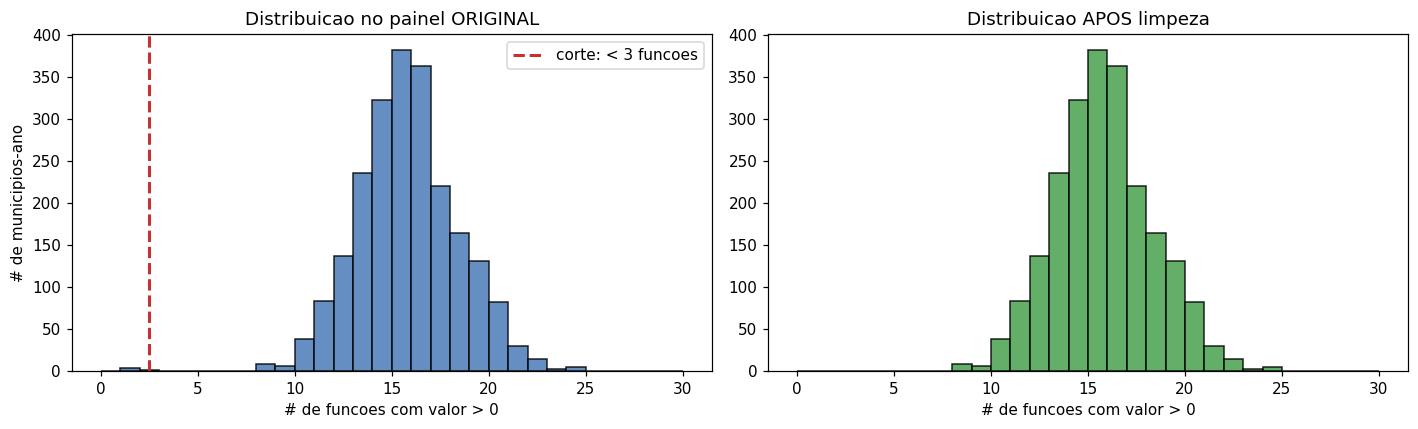

Linhas removidas pelo corte de declaracao incompleta: 5

Municipios-ano cortados:
             municipio  ano  populacao  n_funcoes  total_despesas
             Guaratuba 2023      42207          2     30856722.61
            Jataizinho 2021      12687          1     40486268.14
Nova América da Colina 2020       3434          1     17093501.38
Nova América da Colina 2021       3424          1     17093501.38
          Nova Olímpia 2025       5982          1      3903022.71

Resumo:
  Antes:   2231 linhas
  Depois:  2226 linhas  (99.8%)


In [8]:
# Reconstruir o painel original (raw_df) e o limpo (df) lado a lado
# para inspecao do que o pre-processamento fez.
antes = raw_df.copy()
depois = df.copy()

# 1) Histograma de # de funcoes declaradas no painel ORIGINAL
n_decl_antes = (antes[COL_FUNCOES] > 0).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(n_decl_antes, bins=range(0, 31), color='#4a7ab8', alpha=0.85,
             edgecolor='black')
axes[0].axvline(2.5, color='#c53030', ls='--', lw=2, label='corte: < 3 funcoes')
axes[0].set_xlabel('# de funcoes com valor > 0')
axes[0].set_ylabel('# de municipios-ano')
axes[0].set_title('Distribuicao no painel ORIGINAL')
axes[0].legend()

# 2) Distribuicao apos corte
n_decl_depois = (depois[COL_FUNCOES] > 0).sum(axis=1)
axes[1].hist(n_decl_depois, bins=range(0, 31), color='#48a14d', alpha=0.85,
             edgecolor='black')
axes[1].set_xlabel('# de funcoes com valor > 0')
axes[1].set_title('Distribuicao APOS limpeza')

plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_3_1_limpeza_dist.png', bbox_inches='tight')
plt.show()

# 3) Listar quem foi cortado (declaracoes < 3 funcoes)
cortados = antes[(antes[COL_FUNCOES] > 0).sum(axis=1) < 3].copy()
cortados['n_funcoes'] = (cortados[COL_FUNCOES] > 0).sum(axis=1)
print(f'Linhas removidas pelo corte de declaracao incompleta: {len(cortados)}')
if len(cortados) > 0:
    print('\nMunicipios-ano cortados:')
    print(cortados[['municipio', 'ano', 'populacao', 'n_funcoes',
                    'total_despesas']].to_string(index=False))

print(f'\nResumo:')
print(f'  Antes:  {len(antes):>5} linhas')
print(f'  Depois: {len(depois):>5} linhas  ({len(depois)/len(antes)*100:.1f}%)')



In [9]:
# Comparativo: estatisticas descritivas antes/depois para 4 funcoes-chave
# Mostra que a distribuicao geral nao foi distorcida pelo corte.
funcoes_olhar = ['saude', 'educacao', 'administracao', 'total_despesas']

resumo = []
for f in funcoes_olhar:
    resumo.append({
        'Funcao': f,
        'Mediana antes (R$ M)': antes[f].median() / 1e6,
        'Mediana depois (R$ M)': depois[f].median() / 1e6,
        'Media antes (R$ M)':   antes[f].mean() / 1e6,
        'Media depois (R$ M)':  depois[f].mean() / 1e6,
        'Max antes (R$ M)':     antes[f].max() / 1e6,
        'Max depois (R$ M)':    depois[f].max() / 1e6,
    })
resumo = pd.DataFrame(resumo).round(2)
print('Comparativo descritivo antes vs depois da limpeza (R$ milhoes):')
print(resumo.to_string(index=False))



Comparativo descritivo antes vs depois da limpeza (R$ milhoes):
        Funcao  Mediana antes (R$ M)  Mediana depois (R$ M)  Media antes (R$ M)  Media depois (R$ M)  Max antes (R$ M)  Max depois (R$ M)
         saude                 13.32                  13.33               38.64                38.72           3411.26            3411.26
      educacao                 11.94                  11.96               34.00                34.08           2533.69            2533.69
 administracao                  6.19                   6.19               15.02                15.04            980.93             980.93
total_despesas                 53.18                  53.28              150.51               150.80          13023.96           13023.96


In [10]:
# Estado da linha-ancora APOS a limpeza
ancora = lupa(df)
if ancora is None:
    print(f'AVISO: {ANCORA_NOME} ({ANCORA_ANO}) foi removido pela limpeza!')
else:
    print(f'== {ANCORA_NOME} ({ANCORA_ANO}) — apos LIMPEZA ==')
    print(f'  Sobreviveu ao corte (>= 3 funcoes declaradas).')
    print(f'  n_funcoes_declaradas: {ancora["n_funcoes_declaradas"]}')
    print(f'  flag_negativo:        {ancora["flag_negativo"]}')



== Porto Rico (2024) — apos LIMPEZA ==
  Sobreviveu ao corte (>= 3 funcoes declaradas).
  n_funcoes_declaradas: 16
  flag_negativo:        False


## 4 — Features

| Família | Pergunta | Como funciona |
|---|---|---|
| **Per capita** | Gastou muito ou pouco em valor absoluto? | valor / população |
| **Proporção** | Como distribuiu o orçamento? | valor / total |
| **Variação** | Mudou bruscamente vs ano anterior? | Δ% ano-a-ano |
| **Cluster** | Como se compara com cidades parecidas? | Agrupa cidades similares e mede desvio |
| **Contexto** | Porte e concentração geral | log_pop, HHI |

A família **Cluster** é a chave. Cidades de portes/perfis muito diferentes
não deveriam ser comparadas diretamente — Curitiba e uma cidade de 2 mil
habitantes têm dinâmicas distintas. Antes de criar features comparativas,
agrupamos as cidades em "famílias" parecidas e medimos quanto cada uma
desvia da sua família.

#### Glossário rápido dos sufixos

Para tornar a leitura dos gráficos mais simples, cada feature segue um padrão:

| Sufixo | Significado | Exemplo |
|---|---|---|
| `_pc` | Valor em R$ por habitante | `saude_pc` = R$ gastos em saúde por habitante |
| `_prop` | Proporção do gasto total (0 a 1) | `saude_prop` = 0,30 → 30% do orçamento em saúde |
| `_var` | Variação percentual vs ano anterior | `saude_var` = 0,5 → cresceu 50% |
| `_dev` | Desvio da mediana do cluster, em IQRs | `saude_dev` = +3 → 3 IQRs acima do grupo |

### 4.1 — Per capita (`*_pc`)

Divide o gasto absoluto pela população. Sem essa normalização, Curitiba
domina toda análise só por ser grande. O gráfico abaixo mostra a
distribuição em três funções centrais — **note as caudas longas**: a
maioria dos municípios fica concentrada na faixa baixa, mas alguns
extremos (canto direito) gastam várias vezes mais que a mediana.



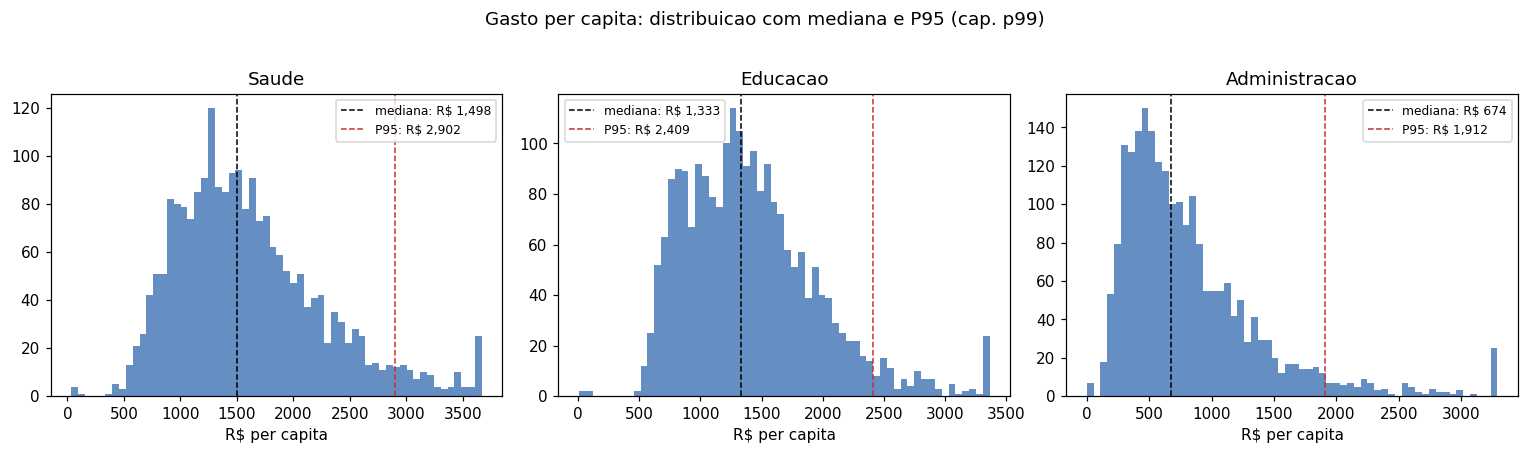

Features per capita: 29


In [11]:
PC_COLS = []
for f in COL_FUNCOES:
    c = f + '_pc'
    df[c] = df[f] / df['populacao'].clip(lower=1)
    PC_COLS.append(c)
df['total_pc'] = df['total_despesas'] / df['populacao'].clip(lower=1)

# Distribuicao das 3 funcoes mais relevantes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, titulo in zip(
    axes,
    ['saude_pc', 'educacao_pc', 'administracao_pc'],
    ['Saude', 'Educacao', 'Administracao']):
    s = df[col].clip(upper=df[col].quantile(0.99))
    ax.hist(s, bins=60, color='#4a7ab8', alpha=0.85)
    ax.axvline(s.median(), color='black', ls='--', lw=1, label=f'mediana: R$ {s.median():,.0f}')
    ax.axvline(s.quantile(0.95), color='#c53030', ls='--', lw=1,
               label=f'P95: R$ {s.quantile(0.95):,.0f}')
    ax.set_title(titulo); ax.set_xlabel('R$ per capita')
    ax.legend(fontsize=8)
plt.suptitle('Gasto per capita: distribuicao com mediana e P95 (cap. p99)', y=1.02)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_4_1_per_capita.png', bbox_inches='tight')
plt.show()
print(f'Features per capita: {len(PC_COLS)}')



In [ ]:
ancora = lupa(df)
print(f'== {ANCORA_NOME} ({ANCORA_ANO}) — apos PER CAPITA (familia 1) ==')
print(f'  populacao = {ancora["populacao"]:,} hab')
print()
print(f'  {"Funcao":<22} {"Valor bruto (R$)":>20} {"Per capita (R$/hab)":>22}')
print(f'  {"-"*22} {"-"*20} {"-"*22}')
for f in ['saude', 'educacao', 'administracao', 'urbanismo',
          'assistencia_social', 'transporte']:
    bruto = ancora[f]
    pc = ancora[f + '_pc']
    print(f'  {LABELS_FUNCAO[f]:<22} {bruto:>20,.0f} {pc:>22,.2f}')



== Porto Rico (2024) — apos PER CAPITA (familia 1) ==
  populacao = 3,316 hab

  Funcao                     Valor bruto (R$)    Per capita (R$/hab)
  ---------------------- -------------------- ----------------------
  Saude                            12,954,205               3,906.58
  Educacao                         10,713,613               3,230.88
  Administracao                     6,909,428               2,083.66
  Urbanismo                        12,880,678               3,884.40
  Assistencia Social                1,297,657                 391.33
  Transporte                        3,005,699                 906.42


### 4.2 — Proporção (`*_prop`)

Para cada função, `valor / total_despesas`. Isso captura **perfil de
gasto** independente do tamanho do município. O gráfico abaixo mostra o
**perfil médio do PR** — onde tipicamente vai cada real gasto. Saúde,
educação e administração somam mais de 60% em quase todos os municípios.
Quem foge muito desse padrão chama atenção.

Os mínimos constitucionais são `saude ≥ 15%` e `educacao ≥ 25%`
(Lei Complementar 141/2012 e art. 212 da CF).

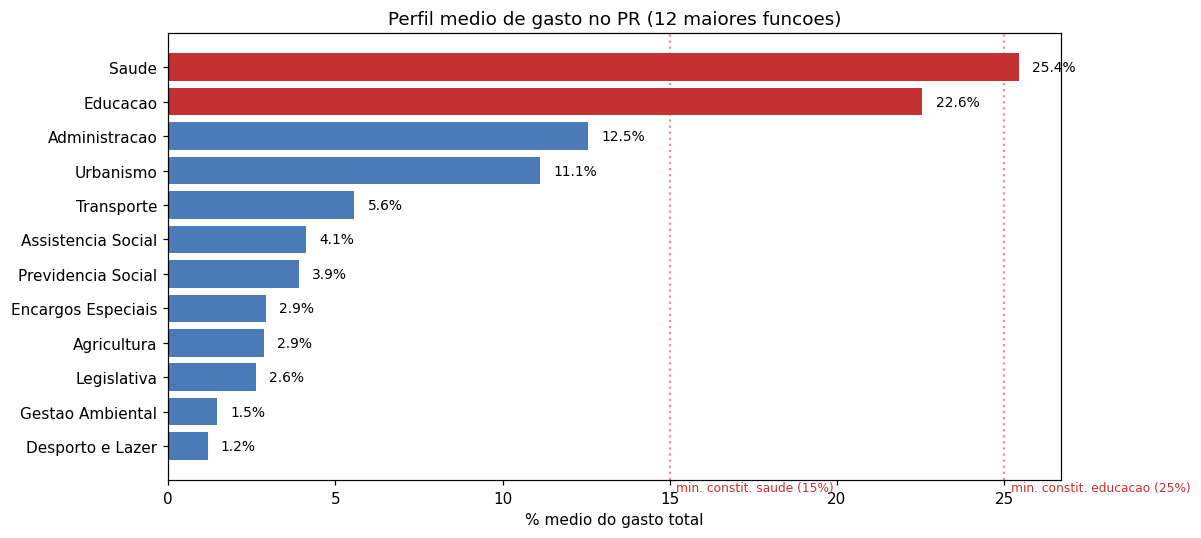

Features proporcao: 29


In [13]:
PROP_COLS = []
tot = df['total_despesas'].clip(lower=1)
for f in COL_FUNCOES:
    c = f + '_prop'
    df[c] = df[f] / tot
    PROP_COLS.append(c)

# Perfil medio do PR: barra horizontal das 12 maiores funcoes
medias = df[PROP_COLS].mean().sort_values(ascending=False).head(12)
labels = [LABELS_FUNCAO.get(c.replace('_prop', ''), c) for c in medias.index]
keys   = [c.replace('_prop', '') for c in medias.index]

fig, ax = plt.subplots(figsize=(11, 5))
cores = ['#c53030' if k in ('saude', 'educacao') else '#4a7ab8' for k in keys]
bars = ax.barh(range(len(labels)), medias.values * 100, color=cores)
for b, v in zip(bars, medias.values * 100):
    ax.text(v + 0.4, b.get_y() + b.get_height()/2, f'{v:.1f}%',
            va='center', fontsize=9)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('% medio do gasto total')
ax.set_title('Perfil medio de gasto no PR (12 maiores funcoes)')
ax.axvline(15, color='#c53030', ls=':', alpha=0.5)
ax.axvline(25, color='#c53030', ls=':', alpha=0.5)
ax.text(15.2, 12.3, 'min. constit. saude (15%)', color='#c53030', fontsize=8)
ax.text(25.2, 12.3, 'min. constit. educacao (25%)', color='#c53030', fontsize=8)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_4_2_proporcao.png', bbox_inches='tight')
plt.show()
print(f'Features proporcao: {len(PROP_COLS)}')



In [ ]:
ancora = lupa(df)
print(f'== {ANCORA_NOME} ({ANCORA_ANO}) — apos PROPORCAO (familia 2) ==')
print(f'  total_despesas = R$ {ancora["total_despesas"]/1e6:,.2f} milhoes')
print()
print(f'  {"Funcao":<22} {"% do gasto":>12} {"Mediana PR":>12}  Status')
print(f'  {"-"*22} {"-"*12} {"-"*12}  ------')
for f in ['saude', 'educacao', 'administracao', 'urbanismo',
          'assistencia_social', 'transporte']:
    prop = ancora[f + '_prop'] * 100
    mediana = df[f + '_prop'].median() * 100
    status = '↑ acima' if prop > mediana else '↓ abaixo'
    print(f'  {LABELS_FUNCAO[f]:<22} {prop:>11.1f}% {mediana:>11.1f}%  {status}')
print()
if ancora['saude_prop'] < 0.15:
    print('  ⚠ Saude abaixo do minimo constitucional (15%)')
if ancora['educacao_prop'] < 0.25:
    print('  ⚠ Educacao abaixo do minimo constitucional (25%)')



== Porto Rico (2024) — apos PROPORCAO (familia 2) ==
  total_despesas = R$ 64.07 milhoes

  Funcao                   % do gasto   Mediana PR  Status
  ---------------------- ------------ ------------  ------
  Saude                         20.2%        25.0%  ↓ abaixo
  Educacao                      16.7%        22.4%  ↓ abaixo
  Administracao                 10.8%        11.3%  ↓ abaixo
  Urbanismo                     20.1%        10.5%  ↑ acima
  Assistencia Social             2.0%         3.9%  ↓ abaixo
  Transporte                     4.7%         4.4%  ↑ acima

  ⚠ Educacao abaixo do minimo constitucional (25%)


### 4.3 — Variação ano-a-ano (`*_var`)

Para cada função-chave: (valor_ano - valor_ano_anterior) / valor_ano_anterior.
Captura saltos: município que dobra o gasto em saúde de um ano pro outro
levanta suspeita, mesmo que o valor absoluto não seja extremo.

Calculamos para 6 funções: saúde, educação, administração, urbanismo,
assistência social, transporte. Valores são limitados a [-500%, +500%]
para que casos extremos não dominem a normalização.

In [15]:
df = df.sort_values(['cod_ibge', 'ano']).reset_index(drop=True)

FUNC_KEY = ['saude', 'educacao', 'administracao', 'urbanismo',
            'assistencia_social', 'transporte']
VAR_COLS = []
for f in FUNC_KEY:
    pc = f + '_pc'
    prev = df.groupby('cod_ibge')[pc].shift(1)
    var = (df[pc] - prev) / prev.replace(0, np.nan)
    df[f + '_var'] = var.clip(-5, 5).fillna(0.0)
    VAR_COLS.append(f + '_var')

# Quantos municipios-ano tem variacao > 100% em pelo menos 1 funcao?
extremos = (df[VAR_COLS].abs() > 1.0).any(axis=1).sum()
print(f'Features variacao: {len(VAR_COLS)}')
print(f'Linhas com pelo menos 1 funcao variando > 100% ano-a-ano: {extremos}'
      f' ({extremos/len(df)*100:.1f}%)')



Features variacao: 6
Linhas com pelo menos 1 funcao variando > 100% ano-a-ano: 460 (20.7%)


In [ ]:
# CIDADE EXEMPLO

ancora = lupa(df)
print(f'== {ANCORA_NOME} ({ANCORA_ANO}) — apos VARIACAO ANO-A-ANO (familia 3) ==')

# Buscar o ano anterior do mesmo municipio para mostrar a comparacao
ano_anterior = df[(df['municipio'] == ANCORA_NOME) &
                  (df['ano'] == ANCORA_ANO - 1)]
print()
if len(ano_anterior) == 0:
    print(f'  {ANCORA_NOME} nao tem dados para {ANCORA_ANO - 1} '
          f'— variacoes sao todas 0 por padrao.')
else:
    prev = ano_anterior.iloc[0]
    print(f'  {"Funcao":<22} {"PC " + str(ANCORA_ANO - 1):>14} '
          f'{"PC " + str(ANCORA_ANO):>14} {"Variacao":>10}')
    print(f'  {"-"*22} {"-"*14} {"-"*14} {"-"*10}')
    for f in FUNC_KEY:
        var = ancora[f + '_var']
        ant = prev[f + '_pc']
        atual = ancora[f + '_pc']
        print(f'  {LABELS_FUNCAO[f]:<22} {ant:>14,.0f} {atual:>14,.0f} '
              f'{var*100:>+9.1f}%')



== Porto Rico (2024) — apos VARIACAO ANO-A-ANO (familia 3) ==

  Funcao                        PC 2023        PC 2024   Variacao
  ---------------------- -------------- -------------- ----------
  Saude                           2,992          3,907     +30.5%
  Educacao                        2,534          3,231     +27.5%
  Administracao                   1,713          2,084     +21.6%
  Urbanismo                       1,158          3,884    +235.4%
  Assistencia Social                385            391      +1.6%
  Transporte                        796            906     +13.8%


### 4.4 — Cluster de cidades parecidas

Em vez de comparar todos os municípios entre si (o que mistura Curitiba com cidade de 2 mil habitantes), agrupamos primeiro por **similaridade de porte e perfil** usando KMeans, e depois construímos features que medem o desvio de cada município contra a **mediana do seu próprio cluster**.

Variáveis usadas no clustering:
- `log(populacao)` — porte demográfico
- `log(total_pc)` — porte do gasto per capita
- `saude_prop`, `educacao_prop`, `administracao_prop` — perfil de prioridades

Usamos **k = 5** clusters (heurística testada: 4 a 6 dão clusters
interpretáveis; mais que isso fragmenta sem ganhar informação).

In [17]:
CLUSTER_FEATS = ['log_pop_cl', 'log_total_pc_cl',
                 'saude_prop_cl', 'educacao_prop_cl', 'administracao_prop_cl']
df['log_pop_cl']             = np.log1p(df['populacao'])
df['log_total_pc_cl']        = np.log1p(df['total_pc'])
df['saude_prop_cl']          = df['saude_prop']
df['educacao_prop_cl']       = df['educacao_prop']
df['administracao_prop_cl']  = df['administracao_prop']

cluster_X = StandardScaler().fit_transform(df[CLUSTER_FEATS].fillna(0))
K = 5
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans.fit_predict(cluster_X)

# Caracterizar cada cluster
print('Caracterizacao dos clusters:')
print('=' * 78)
caract = (df.groupby('cluster')
            .agg(n=('municipio', 'count'),
                 pop_med=('populacao', 'median'),
                 total_pc_med=('total_pc', 'median'),
                 saude_med=('saude_prop', 'median'),
                 educ_med=('educacao_prop', 'median'),
                 adm_med=('administracao_prop', 'median'))
            .round(3))
caract['pop_med']       = caract['pop_med'].astype(int)
caract['total_pc_med']  = caract['total_pc_med'].round(0).astype(int)
caract['saude_med']     = (caract['saude_med'] * 100).round(1).astype(str) + '%'
caract['educ_med']      = (caract['educ_med'] * 100).round(1).astype(str) + '%'
caract['adm_med']       = (caract['adm_med'] * 100).round(1).astype(str) + '%'
print(caract.to_string())



Caracterizacao dos clusters:
           n  pop_med  total_pc_med saude_med educ_med adm_med
cluster                                                       
0        455    11088          4640     31.2%    22.5%   11.0%
1        679    11425          5936     24.3%    23.9%   10.2%
2        352    46377          4050     24.5%    26.6%    8.9%
3        170     6409          5814     24.6%    22.1%   24.8%
4        570     4019          9622     23.3%    18.5%   12.2%


**Visualização dos clusters:** projetamos as 5 dimensões do clustering em
2D usando PCA. Cada ponto é um município-ano, colorido pelo cluster. Os
agrupamentos ficam visíveis: clusters separam por porte populacional
(direita-esquerda) e perfil de gasto (cima-baixo).



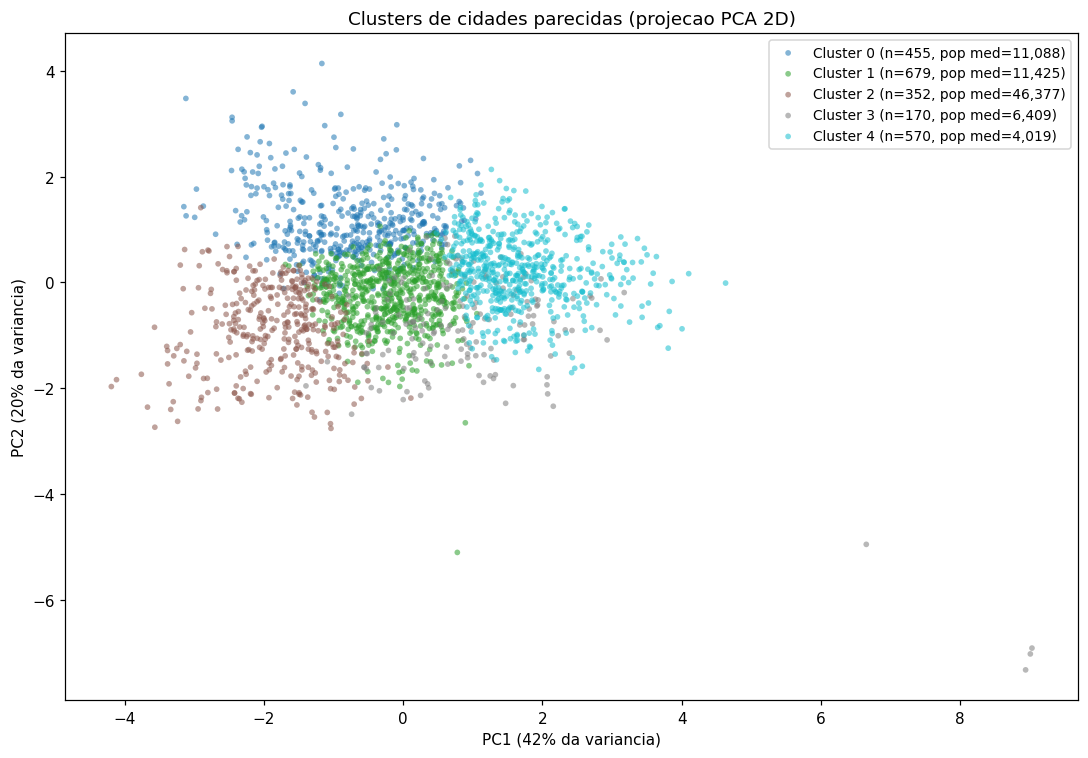

In [18]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
proj = pca.fit_transform(cluster_X)

fig, ax = plt.subplots(figsize=(10, 7))
cores = plt.cm.tab10(np.linspace(0, 1, K))
for k in range(K):
    mask = df['cluster'] == k
    n = mask.sum()
    pop_med = df.loc[mask, 'populacao'].median()
    label = f'Cluster {k} (n={n}, pop med={int(pop_med):,})'
    ax.scatter(proj[mask, 0], proj[mask, 1], s=14, alpha=0.55,
               color=cores[k], label=label, edgecolor='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% da variancia)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% da variancia)')
ax.set_title('Clusters de cidades parecidas (projecao PCA 2D)')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_4_4_clusters.png', bbox_inches='tight')
plt.show()



In [19]:
# Estado da linha-ancora APOS o agrupamento por K-Means
ancora = lupa(df)
cluster_id = int(ancora['cluster'])
caract_cluster = df[df['cluster'] == cluster_id]
print(f'== {ANCORA_NOME} ({ANCORA_ANO}) — apos CLUSTER (familia 4, parte 1) ==')
print(f'  Caiu no cluster #{cluster_id}')
print(f'  Caracteristicas do cluster #{cluster_id}:')
print(f'    n municipios:           {len(caract_cluster)}')
print(f'    populacao mediana:      {int(caract_cluster["populacao"].median()):,}')
print(f'    gasto pc mediana:       R$ {caract_cluster["total_pc"].median():,.0f}')
print(f'    saude (% mediana):      {caract_cluster["saude_prop"].median()*100:.1f}%')
print(f'    educacao (% mediana):   {caract_cluster["educacao_prop"].median()*100:.1f}%')
print(f'    administracao (% med.): {caract_cluster["administracao_prop"].median()*100:.1f}%')
print()
print(f'  Posicao do {ANCORA_NOME} no cluster:')
print(f'    populacao:           {ancora["populacao"]:,}')
print(f'    gasto pc:            R$ {ancora["total_pc"]:,.0f}')



== Porto Rico (2024) — apos CLUSTER (familia 4, parte 1) ==
  Caiu no cluster #4
  Caracteristicas do cluster #4:
    n municipios:           570
    populacao mediana:      4,019
    gasto pc mediana:       R$ 9,622
    saude (% mediana):      23.3%
    educacao (% mediana):   18.5%
    administracao (% med.): 12.2%

  Posicao do Porto Rico no cluster:
    populacao:           3,316
    gasto pc:            R$ 19,323


### 4.5 — Desvio em relação ao cluster (`*_dev`)

Agora que cada município tem um cluster, criamos features que medem
**quanto ele desvia da mediana do seu próprio cluster**. Isso é mais
informativo que comparar com a mediana global do PR, porque cidades
pequenas e grandes têm padrões de gasto naturalmente diferentes.

Para cada função-chave:

```
dev = (valor_pc - mediana_cluster_pc) / IQR_cluster_pc
```

Resultado: número de "IQRs de distância" da mediana do cluster. Valores
3 são fortemente atípicos *para aquele tipo de cidade*. Esta é a
feature mais interpretável do conjunto.



Top 10 maiores desvios em Saude vs mediana do cluster:
              Municipio  Ano  Cluster  Populacao  Saude (R$/hab)  Saude (desvio do cluster)
           Santa Helena 2025        1      26461         3079.75                       3.30
   Nova Aliança do Ivaí 2025        4       1322         4887.83                       3.23
              Miraselva 2022        3       1860         3455.28                       3.04
              Miraselva 2023        3       1934         3347.90                       2.89
  Rancho Alegre D'Oeste 2024        3       2638         3272.61                       2.77
          Jardim Olinda 2024        4       1353         4368.80                       2.60
              Araucária 2024        2     160038         2171.41                       2.59
          Jardim Olinda 2022        4       1324         4353.88                       2.59
                 Kaloré 2023        4       4437         4345.11                       2.58
Coronel Domingos Soares 2

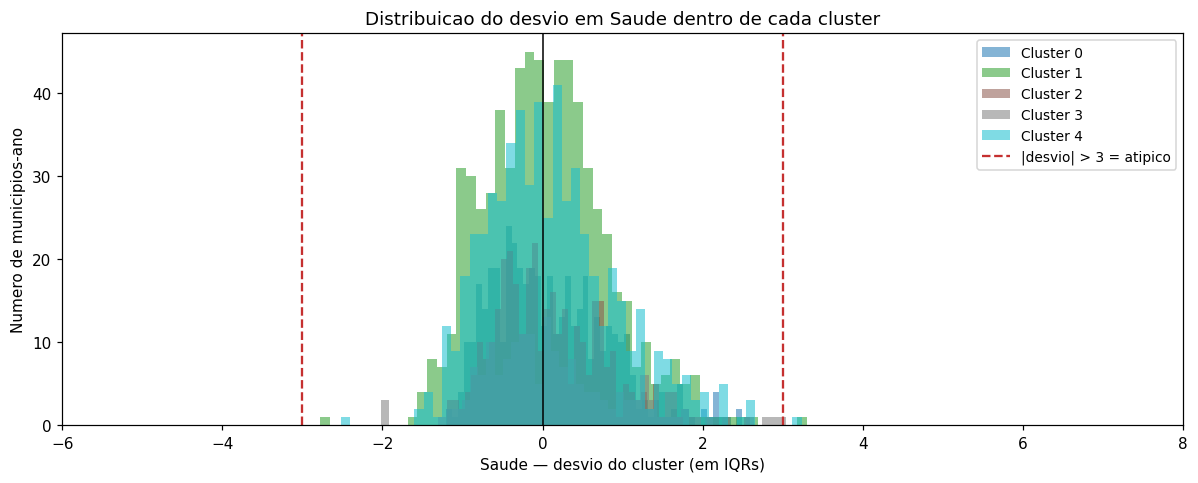


Features desvio do cluster: 6


In [20]:
DEV_COLS = []
for f in FUNC_KEY:
    pc = f + '_pc'
    grp = df.groupby('cluster')[pc]
    med = grp.transform('median')
    q1  = grp.transform(lambda s: s.quantile(0.25))
    q3  = grp.transform(lambda s: s.quantile(0.75))
    iqr = (q3 - q1).replace(0, np.nan)
    dev = (df[pc] - med) / iqr
    df[f + '_dev'] = dev.clip(-10, 10).fillna(0.0)
    DEV_COLS.append(f + '_dev')

# Top 10 maiores desvios em saude_pc (com rotulos amigaveis)
top_dev_saude = df.nlargest(10, 'saude_dev')[
    ['municipio', 'ano', 'cluster', 'populacao', 'saude_pc', 'saude_dev']].copy()
top_dev_saude.columns = ['Municipio', 'Ano', 'Cluster', 'Populacao',
                          'Saude (R$/hab)', 'Saude (desvio do cluster)']
print('Top 10 maiores desvios em Saude vs mediana do cluster:')
print(top_dev_saude.round(2).to_string(index=False))

# Grafico: distribuicao de saude_dev
fig, ax = plt.subplots(figsize=(11, 4.5))
for k in range(K):
    sub = df[df['cluster'] == k]['saude_dev']
    ax.hist(sub, bins=50, alpha=0.55, label=f'Cluster {k}', color=cores[k])
ax.axvline(0, color='black', lw=1)
ax.axvline(3, color='#c53030', ls='--', label='|desvio| > 3 = atipico')
ax.axvline(-3, color='#c53030', ls='--')
ax.set_xlabel('Saude — desvio do cluster (em IQRs)')
ax.set_ylabel('Numero de municipios-ano')
ax.set_title('Distribuicao do desvio em Saude dentro de cada cluster')
ax.set_xlim(-6, 8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_4_5_desvio.png', bbox_inches='tight')
plt.show()
print(f'\nFeatures desvio do cluster: {len(DEV_COLS)}')



In [ ]:
# CIDADE EXEMPLO

ancora = lupa(df)
cluster_id = int(ancora['cluster'])
print(f'== {ANCORA_NOME} ({ANCORA_ANO}) — apos DESVIO DO CLUSTER (familia 4, parte 2) ==')
print(f'  Quanto este municipio se desvia da mediana do cluster #{cluster_id},')
print(f'  medido em IQRs (intervalos interquartis):')
print()
print(f'  {"Funcao":<22} {"Valor PC":>12} {"Med cluster":>14} '
      f'{"IQR cluster":>14} {"Desvio":>10}')
print(f'  {"-"*22} {"-"*12} {"-"*14} {"-"*14} {"-"*10}')
for f in FUNC_KEY:
    pc = f + '_pc'
    grp = df[df['cluster'] == cluster_id][pc]
    med = grp.median()
    iqr = grp.quantile(0.75) - grp.quantile(0.25)
    valor = ancora[pc]
    dev = ancora[f + '_dev']
    flag = '  ⚠ atipico' if abs(dev) >= 3 else ''
    print(f'  {LABELS_FUNCAO[f]:<22} {valor:>12,.0f} {med:>14,.0f} '
          f'{iqr:>14,.0f} {dev:>+9.2f}{flag}')



== Porto Rico (2024) — apos DESVIO DO CLUSTER (familia 4, parte 2) ==
  Quanto este municipio se desvia da mediana do cluster #4,
  medido em IQRs (intervalos interquartis):

  Funcao                     Valor PC    Med cluster    IQR cluster     Desvio
  ---------------------- ------------ -------------- -------------- ----------
  Saude                         3,907          2,222            824     +2.04
  Educacao                      3,231          1,808            761     +1.87
  Administracao                 2,084          1,171            598     +1.53
  Urbanismo                     3,884          1,132            951     +2.89
  Assistencia Social              391            411            259     -0.08
  Transporte                      906            563            837     +0.41


### 4.6 — Contexto: porte e concentração

#### `log_pop` — porte demográfico em escala logarítmica

A população dos municípios do PR varia de **~1.000 a ~2.000.000**
habitantes — três ordens de grandeza. Em escala linear, Curitiba sozinha
dominaria qualquer cálculo de distância (a diferença entre Curitiba e
Apucarana é mil vezes maior do que entre Apucarana e uma cidade pequena,
mesmo que essa última seja muito mais "parecida" com Apucarana do que
Curitiba).

A transformação `log(1 + pop)` comprime essa escala. Em log:
- Cidade de 1k hab → log_pop ≈ 6,9
- Cidade de 100k hab → log_pop ≈ 11,5
- Curitiba (~1,9M) → log_pop ≈ 14,5

#### `hhi` — concentração do gasto (Herfindahl-Hirschman Index)

```
hhi = soma( prop_funcao² )   para todas as 29 funções
```

É a soma dos quadrados das proporções de cada função no gasto total. Vai
de `1/29 ≈ 0.034` (gasto perfeitamente distribuído) até `1.0` (tudo numa
única função).

**Por que isso é informativo?** Um município que distribui o gasto entre
muitas funções (saúde, educação, urbanismo, saneamento, transporte...)
tem HHI baixo — perfil saudável. Quem concentra tudo em 2-3 funções
(tipicamente `administração` e `encargos especiais`, com pouco em saúde
e educação) tem HHI alto.

Exemplos típicos no dataset:
- HHI ≈ 0,12 → perfil distribuído, ~10 funções com peso similar
- HHI ≈ 0,25 → 4-5 funções dominam
- HHI ≈ 0,40+ → 2-3 funções concentram quase todo o gasto

In [22]:
df['log_pop'] = np.log1p(df['populacao'])
df['hhi']     = (df[PROP_COLS] ** 2).sum(axis=1)
CTX_COLS = ['log_pop', 'hhi']

FEATURES = PC_COLS + PROP_COLS + VAR_COLS + DEV_COLS + CTX_COLS
print(f'TOTAL DE FEATURES: {len(FEATURES)}')
print(f'  per_capita:         {len(PC_COLS)}')
print(f'  proporcao:          {len(PROP_COLS)}')
print(f'  variacao_aa:        {len(VAR_COLS)}')
print(f'  desvio_cluster:     {len(DEV_COLS)}')
print(f'  contexto:           {len(CTX_COLS)}')

print()
print('Estatisticas das features de contexto:')
print(df[['log_pop', 'hhi']].describe().round(3).to_string())



TOTAL DE FEATURES: 72
  per_capita:         29
  proporcao:          29
  variacao_aa:        6
  desvio_cluster:     6
  contexto:           2

Estatisticas das features de contexto:
        log_pop       hhi
count  2226.000  2226.000
mean      9.312     0.173
std       1.114     0.040
min       7.178     0.106
25%       8.504     0.153
50%       9.172     0.168
75%       9.848     0.188
max      14.490     0.972


In [ ]:
# CIDADE EXEMPLO

ancora = lupa(df)
print(f'== {ANCORA_NOME} ({ANCORA_ANO}) — apos CONTEXTO (familia 5) ==')
print(f'  populacao:    {ancora["populacao"]:>10,} hab')
print(f'  log_pop:      {ancora["log_pop"]:>13.3f}  '
      f'(escala log para comprimir extremos)')
print()
print(f'  hhi (concentracao do gasto): {ancora["hhi"]:.4f}')
print(f'  Mediana do PR:               {df["hhi"].median():.4f}')
hhi_status = ('↑ acima da mediana — gasto MAIS concentrado'
              if ancora["hhi"] > df["hhi"].median()
              else '↓ abaixo da mediana — gasto MAIS distribuido')
print(f'  {hhi_status}')
print()
print(f'  Total final de features para o ancora: {len(FEATURES)} valores')



== Porto Rico (2024) — apos CONTEXTO (familia 5) ==
  populacao:         3,316 hab
  log_pop:              8.107  (escala log para comprimir extremos)

  hhi (concentracao do gasto): 0.1391
  Mediana do PR:               0.1685
  ↓ abaixo da mediana — gasto MAIS distribuido

  Total final de features para o ancora: 72 valores


### 4.7 — Como as 74 features alimentam Isolation Forest e LOF

As 5 famílias de features que construímos têm propósitos
complementares. Aqui mostramos como cada algoritmo "lê" o conjunto.

#### O espaço de busca

Cada município-ano vira um **ponto em 74 dimensões**. Cada eixo é uma
feature: `saude_pc`, `educacao_prop`, `saude_var`, `saude_dev`,
`log_pop`, `hhi`, etc. O dataset inteiro (2.227 municípios-ano) é uma
nuvem de pontos nesse espaço.

> **Anomalia = ponto distante do resto da nuvem em várias dimensões
> simultaneamente.**

Não basta ser extremo em uma dimensão. Um município pode ter `saude_pc`
alto porque é rico — isso não é anomalia. Mas se ele tem `saude_pc`
alto, `educacao_prop` baixo, `administracao_dev` muito alto e `hhi` em
nível incomum tudo ao mesmo tempo, **aí o ponto está em uma região
vazia do espaço** — é nisso que IF e LOF se concentram.

#### O papel de cada família

| Família | Eixos no espaço | Tipo de anomalia que captura |
|---|---|---|
| Per capita (29) | Valor absoluto por habitante | Cidade gastando muito ou muito pouco em uma função |
| Proporção (29) | Como divide o orçamento | Cidade com perfil de prioridades atípico |
| Variação (6) | Saltos ano-a-ano | Mudança brusca, possível obra/operação pontual |
| Desvio cluster (6) | Distância da mediana do grupo | Cidade atípica para o seu próprio porte |
| Contexto (4) | Porte e concentração | Calibra os outros eixos |

Sem proporção, perderíamos cidades pequenas com perfil enviesado.
Sem desvio_cluster, cidades pequenas com gasto naturalmente alto seriam
falsos positivos. Sem variação, fraudes pontuais (1 ano só) seriam
diluídas. **As famílias se complementam — nenhuma sozinha basta.**


## 5 — Normalização

In [ ]:
# RobustScaler (mediana + IQR)

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(df[FEATURES])
scaler = RobustScaler()
X = scaler.fit_transform(X_imp)
print(f'X: {X.shape}  '
      f'(mediana={np.median(X):.3f}, IQR={np.percentile(X,75)-np.percentile(X,25):.3f})')

# Exporta o dataset PRE-NORMALIZACAO para inspecao manual
# (todas as features brutas + identificadores; voce pode abrir no Excel)
df.to_csv(EXPORTS_DIR / 'pre_process.csv', index=False)
print(f'pre_process.csv : {len(df):,} linhas x {df.shape[1]} colunas '
      f'(features brutas, antes da normalizacao)')

# Exporta tambem o X normalizado com identificadores, para inspecao do que
# IF e LOF realmente "veem" como entrada
X_df = pd.DataFrame(X, columns=FEATURES)
X_df.insert(0, 'ano',       df['ano'].values)
X_df.insert(0, 'municipio', df['municipio'].values)
X_df.insert(0, 'cod_ibge',  df['cod_ibge'].values)
X_df.to_csv(EXPORTS_DIR / 'features_normalizadas.csv', index=False)
print(f'features_normalizadas.csv : {X_df.shape[0]:,} linhas x {X_df.shape[1]} colunas')



X: (2226, 72)  (mediana=0.000, IQR=0.436)
pre_process.csv : 2,226 linhas x 115 colunas (features brutas, antes da normalizacao)
features_normalizadas.csv : 2,226 linhas x 75 colunas


### CIDADE EXEMPLO - 2


In [25]:
# Posicao do ancora na matriz X
mask = (df['municipio'] == ANCORA_NOME) & (df['ano'] == ANCORA_ANO)
idx_ancora = df.index[mask][0] if mask.any() else None

if idx_ancora is None:
    print(f'AVISO: {ANCORA_NOME} ({ANCORA_ANO}) nao encontrado.')
else:
    print(f'== {ANCORA_NOME} ({ANCORA_ANO}) — apos NORMALIZACAO ==')
    print(f'  Linha {idx_ancora} na matriz X (shape {X.shape})')
    print()

    # Mostrar antes/depois para 8 features de familias diferentes
    amostra = ['saude_pc', 'educacao_pc', 'administracao_pc',
               'saude_prop', 'educacao_prop',
               'saude_var', 'saude_dev', 'log_pop']
    indices_amostra = [FEATURES.index(f) for f in amostra]
    print(f'  {"Feature":<32} {"Antes (bruto)":>15} {"Depois (norm)":>15}')
    print(f'  {"-"*32} {"-"*15} {"-"*15}')
    for f, idx_f in zip(amostra, indices_amostra):
        bruto = X_imp[idx_ancora, idx_f]
        norm  = X[idx_ancora, idx_f]
        print(f'  {pretty(f)[:32]:<32} {bruto:>15,.3f} {norm:>15,.3f}')
    print()
    print(f'  Quanto mais distante de 0 (em modulo) o valor "depois",')
    print(f'  mais atipica a feature do {ANCORA_NOME} esta nessa dimensao.')
    n_extremas = int((np.abs(X[idx_ancora]) > 3).sum())
    print(f'  Features com |valor| > 3 IQRs: {n_extremas} de {len(FEATURES)}')



== Porto Rico (2024) — apos NORMALIZACAO ==
  Linha 1567 na matriz X (shape (2226, 72))

  Feature                            Antes (bruto)   Depois (norm)
  -------------------------------- --------------- ---------------
  Saude (R$ por habitante)               3,906.576           2.927
  Educacao (R$ por habitante)            3,230.884           2.695
  Administracao (R$ por habitante)       2,083.664           2.320
  Saude (% do gasto total)                   0.202          -0.856
  Educacao (% do gasto total)                0.167          -0.978
  Saude (variacao ano-a-ano)                 0.305           0.999
  Saude (desvio do cluster)                  2.044           2.058
  Porte populacional (log)                   8.107          -0.793

  Quanto mais distante de 0 (em modulo) o valor "depois",
  mais atipica a feature do Porto Rico esta nessa dimensao.
  Features com |valor| > 3 IQRs: 10 de 72


## 6 — Detecção: Isolation Forest e LOF (comparação)

Aplicamos os **dois algoritmos separadamente**, cada um com seu próprio
escore de anomalia normalizado para [0, 1]. A análise comparativa é o foco:
queremos entender **onde os dois concordam e onde divergem**.

### Critério de classificação
Para cada algoritmo, classificamos como "Anômalo" o município-ano cujo
escore esteja no **top 2%** (acima do percentil 98). Isso é independente
para cada algoritmo, então um município pode ser anômalo só pelo IF, só
pelo LOF, por ambos, ou por nenhum.

### Quatro grupos de comparação
- **Ambos**: detectado pelos dois — anomalia mais robusta
- **Apenas IF**: detectado só pelo Isolation Forest — provável anomalia *global*
- **Apenas LOF**: detectado só pelo LOF — provável anomalia *local*
- **Nenhum**: dentro do padrão normal

In [26]:
# =====================================================================
# 6.1 — ISOLATION FOREST
# =====================================================================
# Constroi 300 arvores. Em cada arvore, particiona o espaco aleatoriamente:
# escolhe uma feature ao acaso, escolhe um valor de corte aleatorio, parte o
# conjunto. Repete ate cada ponto ficar isolado.
#
# Pontos anomalos sao isolados em POUCAS particoes (profundidade media baixa)
# porque sao raros/diferentes. Pontos normais demoram mais (profundidade alta).
#
# Parametros:
#   n_estimators=300    : numero de arvores. Mais arvores = score mais estavel.
#   contamination='auto': nao impomos a priori a fracao de anomalias —
#                         deixamos o algoritmo decidir e usamos so o score.
#   random_state=42     : reprodutibilidade.
#   n_jobs=-1           : paraleliza nos nucleos disponiveis.
iso = IsolationForest(n_estimators=300, contamination='auto',
                      random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X)

# score_samples retorna a "pontuacao de normalidade":
#   - VALORES ALTOS  = ponto normal (precisa muitas particoes para isolar)
#   - VALORES BAIXOS = ponto anomalo (poucas particoes bastam)
# Invertemos o sinal para que MAIS ALTO = MAIS ANOMALO (mais intuitivo).
if_raw = -iso.score_samples(X)

# Normaliza para [0, 1] via min-max so para facilitar comparacao com LOF.
# Nao muda a ordem dos pontos, apenas reescala.
if_norm = (if_raw - if_raw.min()) / (if_raw.max() - if_raw.min())
df['score_if'] = if_norm

print(f'Isolation Forest treinado.')
print(f'  Score bruto:      min={if_raw.min():.3f}  max={if_raw.max():.3f}')
print(f'  Score normalizado: P50={np.percentile(if_norm, 50):.3f}  '
      f'P95={np.percentile(if_norm, 95):.3f}  P98={np.percentile(if_norm, 98):.3f}')



Isolation Forest treinado.
  Score bruto:      min=0.330  max=0.563
  Score normalizado: P50=0.166  P95=0.491  P98=0.635


In [27]:
# =====================================================================
# 6.2 — LOCAL OUTLIER FACTOR
# =====================================================================
# Para cada ponto, olha os 20 vizinhos mais proximos e compara a densidade
# local DELE com a densidade media DOS VIZINHOS. Razao alta = ponto em
# regiao esparsa relativa aos vizinhos = anomalia LOCAL.
#
# Diferente do IF (que olha o conjunto inteiro), o LOF olha apenas o
# entorno imediato. Por isso captura anomalias que o IF pode subestimar:
# pontos que nao sao extremos no conjunto, mas sao raros entre seus pares.
#
# Parametros:
#   n_neighbors=20      : tamanho da vizinhanca. Heuristica padrao
#                         (Breunig 2000). Menor = mais sensivel a ruido;
#                         maior = pode mascarar anomalias pequenas.
#   contamination='auto': mesma logica do IF, deixamos o algoritmo decidir.
#   n_jobs=-1           : paraleliza nos nucleos disponiveis.
lof = LocalOutlierFactor(n_neighbors=20, contamination='auto', n_jobs=-1)
lof.fit_predict(X)

# negative_outlier_factor_ guarda o LOF com sinal trocado:
#   - VALORES PROXIMOS DE -1 = ponto normal (densidade similar aos vizinhos)
#   - VALORES MUITO NEGATIVOS = ponto anomalo (regiao esparsa relativa)
# Invertemos para que MAIS ALTO = MAIS ANOMALO (mesma convencao do IF).
lof_raw = -lof.negative_outlier_factor_
lof_norm = (lof_raw - lof_raw.min()) / (lof_raw.max() - lof_raw.min())
df['score_lof'] = lof_norm

print(f'LOF treinado.')
print(f'  Score bruto:      min={lof_raw.min():.3f}  max={lof_raw.max():.3f}')
print(f'  Score normalizado: P50={np.percentile(lof_norm, 50):.3f}  '
      f'P95={np.percentile(lof_norm, 95):.3f}  P98={np.percentile(lof_norm, 98):.3f}')



LOF treinado.
  Score bruto:      min=0.961  max=12.931
  Score normalizado: P50=0.019  P95=0.102  P98=0.170


In [28]:
# =====================================================================
# 6.3 — CLASSIFICACAO INDEPENDENTE: top 2% de cada algoritmo
# =====================================================================
# Cada algoritmo classifica seus proprios outliers usando seu proprio P98.
# Depois cruzamos os dois resultados em 4 categorias.
p98_if  = df['score_if'].quantile(0.98)
p98_lof = df['score_lof'].quantile(0.98)

df['anomalo_if']  = df['score_if']  >= p98_if
df['anomalo_lof'] = df['score_lof'] >= p98_lof

# Categoria de concordancia entre os dois algoritmos
def _categoria(row):
    if   row['anomalo_if'] and row['anomalo_lof']: return 'Ambos'
    elif row['anomalo_if']:                          return 'Apenas IF'
    elif row['anomalo_lof']:                         return 'Apenas LOF'
    else:                                            return 'Nenhum'

df['categoria'] = df.apply(_categoria, axis=1)

print(f'Cortes (top 2% de cada algoritmo):')
print(f'  Isolation Forest: score >= {p98_if:.3f}')
print(f'  LOF:              score >= {p98_lof:.3f}')
print()
print('Distribuicao por categoria:')
print(df['categoria'].value_counts().to_string())

n_if  = df['anomalo_if'].sum()
n_lof = df['anomalo_lof'].sum()
n_amb = ((df['anomalo_if']) & (df['anomalo_lof'])).sum()
n_uniao = ((df['anomalo_if']) | (df['anomalo_lof'])).sum()
jaccard = n_amb / n_uniao if n_uniao > 0 else 0

print(f'\nConcordancia entre os dois algoritmos:')
print(f'  Anomalas em IF:   {n_if:>3}')
print(f'  Anomalas em LOF:  {n_lof:>3}')
print(f'  Em comum (ambos): {n_amb:>3}')
print(f'  Jaccard:          {jaccard:.3f}  '
      f'(0 = sem sobreposicao, 1 = perfeita concordancia)')



Cortes (top 2% de cada algoritmo):
  Isolation Forest: score >= 0.635
  LOF:              score >= 0.170

Distribuicao por categoria:
categoria
Nenhum        2146
Apenas IF       35
Apenas LOF      35
Ambos           10

Concordancia entre os dois algoritmos:
  Anomalas em IF:    45
  Anomalas em LOF:   45
  Em comum (ambos):  10
  Jaccard:          0.125  (0 = sem sobreposicao, 1 = perfeita concordancia)


### CIDADE EXEMPLO - 3

In [ ]:
ancora = lupa(df)
print(f'== {ANCORA_NOME} ({ANCORA_ANO}) — apos DETECCAO ==')
print()
print(f'  Score Isolation Forest:  {ancora["score_if"]:.4f}  '
      f'(corte top 2% = {p98_if:.4f})')
print(f'  Score LOF:               {ancora["score_lof"]:.4f}  '
      f'(corte top 2% = {p98_lof:.4f})')
print()
status_if  = '✓ ANOMALA' if ancora['anomalo_if']  else '✗ normal'
status_lof = '✓ ANOMALA' if ancora['anomalo_lof'] else '✗ normal'
print(f'  Veredito IF:   {status_if}')
print(f'  Veredito LOF:  {status_lof}')
print()
print(f'  >>> CATEGORIA FINAL: {ancora["categoria"].upper()} <<<')
print()

# Posicao no ranking de cada algoritmo
rank_if  = (df['score_if']  > ancora['score_if'] ).sum() + 1
rank_lof = (df['score_lof'] > ancora['score_lof']).sum() + 1
print(f'  Posicao no ranking (de {len(df)} municipios-ano):')
print(f'    pelo IF:  {rank_if}')
print(f'    pelo LOF: {rank_lof}')

== Porto Rico (2024) — apos DETECCAO ==

  Score Isolation Forest:  0.9689  (corte top 2% = 0.6354)
  Score LOF:               0.1734  (corte top 2% = 0.1699)

  Veredito IF:   ✓ ANOMALA
  Veredito LOF:  ✓ ANOMALA

  >>> CATEGORIA FINAL: AMBOS <<<

  Posicao no ranking (de 2226 municipios-ano):
    pelo IF:  2
    pelo LOF: 42


### 6.4 — Raio-X comparativo: por que IF e LOF discordam?

Pegamos **um exemplo de cada categoria** e mostramos lado a lado quais
features estão mais distantes da mediana global do dataset (em IQRs).
Esta visualização explica:

- **Ambos**: o ponto é atípico em muitas dimensões → ambos detectam
- **Apenas IF**: o ponto está globalmente longe da nuvem (várias features
  extremas), mas tem vizinhos parecidos → IF detecta, LOF não
- **Apenas LOF**: o ponto está localmente isolado (poucos vizinhos
  próximos), mas seus valores absolutos não são extremos → LOF detecta,
  IF subestima



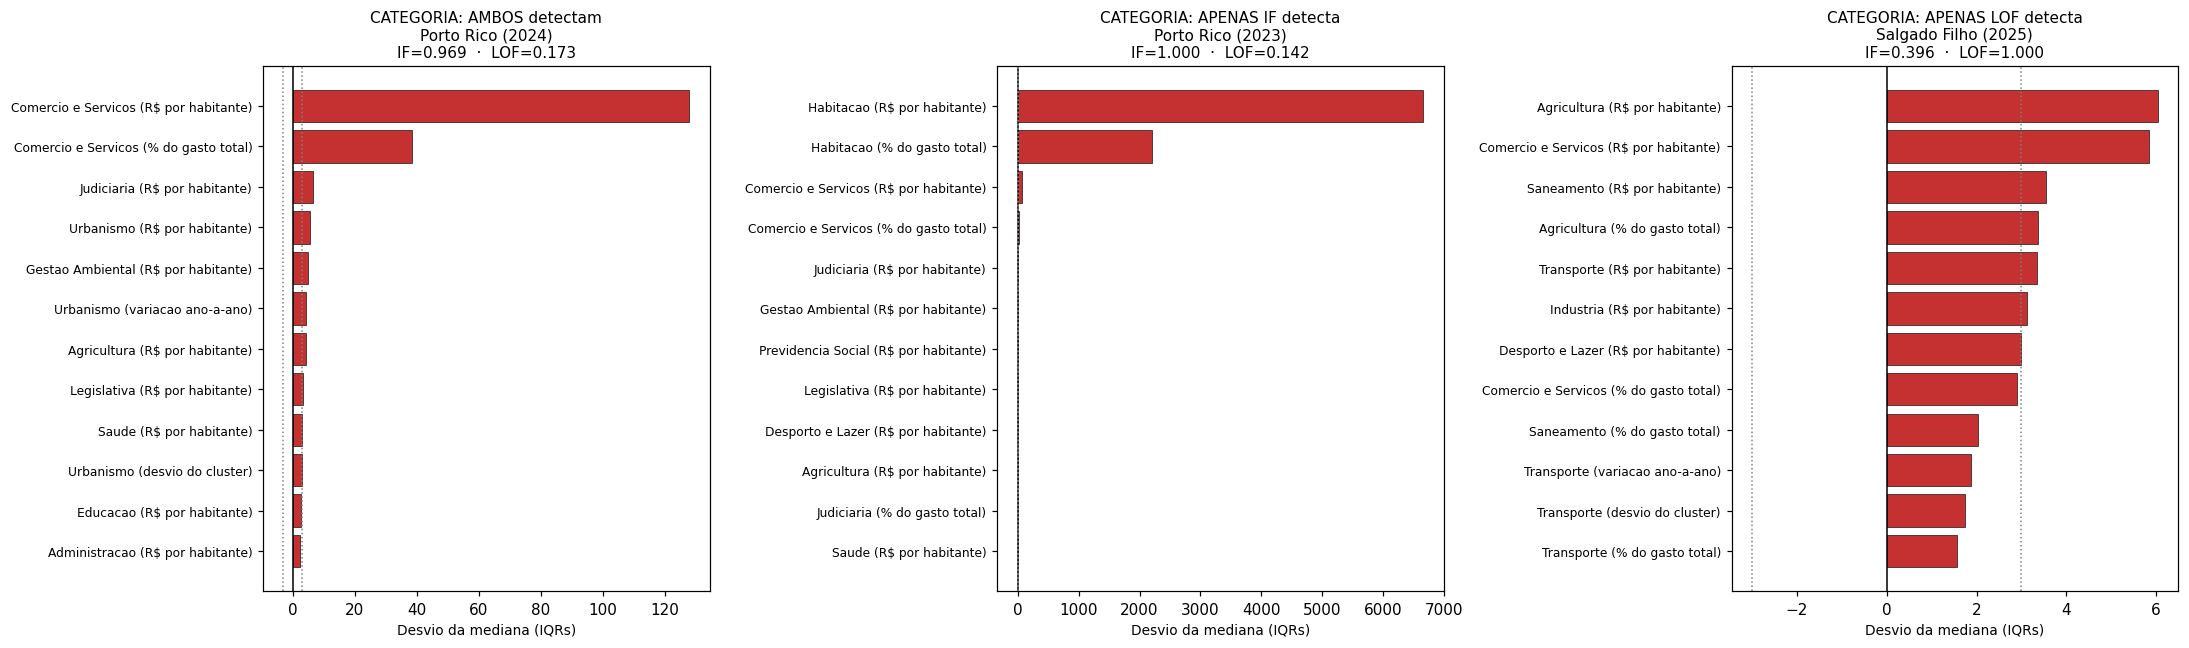

Resumo: quantas features cada caso tem com |desvio| > 3 IQRs:
(quanto mais features atipicas, mais facil para IF detectar)
  Ambos       : Porto Rico                     (2024)  -> 8 features extremas
  Apenas IF   : Porto Rico                     (2023)  -> 8 features extremas
  Apenas LOF  : Salgado Filho                  (2025)  -> 6 features extremas


In [30]:
def raio_x(idx, ax, titulo_cor):
    """Plota as 12 features mais extremas do ponto (em IQRs globais)."""
    row = df.loc[idx]
    medianas = df[FEATURES].median()
    q1 = df[FEATURES].quantile(0.25)
    q3 = df[FEATURES].quantile(0.75)
    iqr = (q3 - q1).replace(0, np.nan)
    z = (row[FEATURES] - medianas) / iqr

    top = z.abs().sort_values(ascending=False).head(12)
    nomes = [pretty(n) for n in top.index]
    valores = z[top.index].values

    cores = ['#c53030' if v > 0 else '#2c5282' for v in valores]
    ax.barh(range(len(nomes)), valores, color=cores, edgecolor='black', lw=0.4)
    ax.set_yticks(range(len(nomes)))
    ax.set_yticklabels(nomes, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0, color='black', lw=1)
    ax.axvline(3, color='gray', ls=':', lw=1)
    ax.axvline(-3, color='gray', ls=':', lw=1)
    ax.set_xlabel('Desvio da mediana (IQRs)', fontsize=9)
    ax.set_title(f'{titulo_cor}\n{row["municipio"]} ({row["ano"]})\n'
                 f'IF={row["score_if"]:.3f}  ·  LOF={row["score_lof"]:.3f}',
                 fontsize=10)


# Selecionar UM caso de cada categoria, com o maior score na sua categoria
def melhor_da_categoria(cat, ranking_por):
    sub = df[df['categoria'] == cat]
    if len(sub) == 0:
        return None
    return sub.nlargest(1, ranking_por).index[0]

idx_ambos    = melhor_da_categoria('Ambos',      'score_if')
idx_so_if    = melhor_da_categoria('Apenas IF',  'score_if')
idx_so_lof   = melhor_da_categoria('Apenas LOF', 'score_lof')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
if idx_ambos is not None:
    raio_x(idx_ambos, axes[0], 'CATEGORIA: AMBOS detectam')
if idx_so_if is not None:
    raio_x(idx_so_if, axes[1], 'CATEGORIA: APENAS IF detecta')
if idx_so_lof is not None:
    raio_x(idx_so_lof, axes[2], 'CATEGORIA: APENAS LOF detecta')
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_6_1_raio_x_comparativo.png', bbox_inches='tight')
plt.show()

# Reporte textual: quantas features cada um tem com |desvio| > 3 IQRs
def n_atipicas(idx):
    row = df.loc[idx]
    medianas = df[FEATURES].median()
    iqr = (df[FEATURES].quantile(0.75) - df[FEATURES].quantile(0.25)).replace(0, np.nan)
    z = (row[FEATURES] - medianas) / iqr
    return int((z.abs() > 3).sum())

print('Resumo: quantas features cada caso tem com |desvio| > 3 IQRs:')
print('(quanto mais features atipicas, mais facil para IF detectar)')
for cat, idx in [('Ambos', idx_ambos), ('Apenas IF', idx_so_if),
                 ('Apenas LOF', idx_so_lof)]:
    if idx is None: continue
    row = df.loc[idx]
    print(f'  {cat:12s}: {row["municipio"]:30s} ({row["ano"]})  '
          f'-> {n_atipicas(idx)} features extremas')



## 7 — Resultados: comparação entre IF e LOF

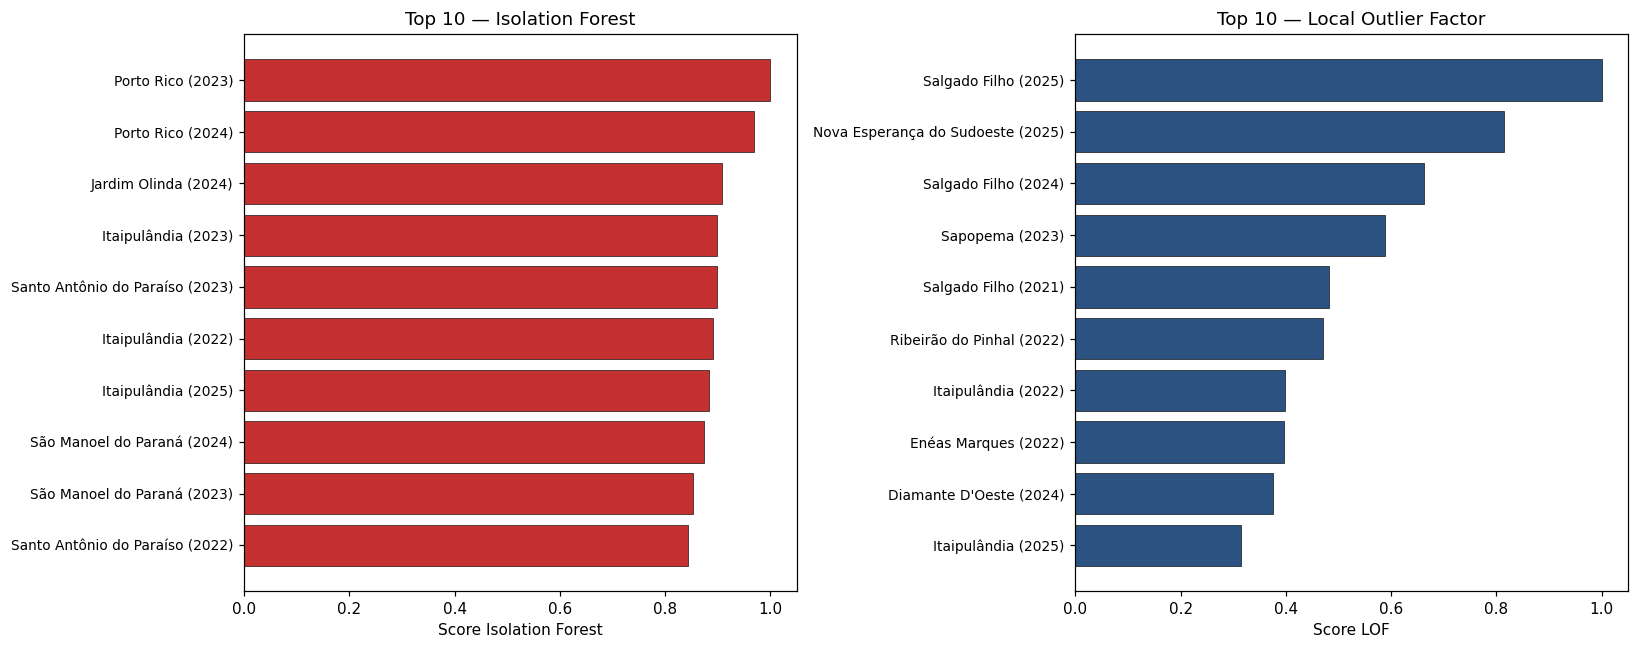

Intersecao top 10 IF e top 10 LOF: 2 municipios-ano


In [31]:
# 7.1 — Top 10 de cada algoritmo lado a lado
top10_if  = df.nlargest(10, 'score_if')
top10_lof = df.nlargest(10, 'score_lof')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

labels_if = [f'{m} ({a})' for m, a in zip(top10_if['municipio'], top10_if['ano'])]
axes[0].barh(range(len(top10_if)), top10_if['score_if'].values,
             color='#c53030', edgecolor='black', linewidth=0.4)
axes[0].set_yticks(range(len(top10_if)))
axes[0].set_yticklabels(labels_if, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Score Isolation Forest')
axes[0].set_title('Top 10 — Isolation Forest')

labels_lof = [f'{m} ({a})' for m, a in zip(top10_lof['municipio'], top10_lof['ano'])]
axes[1].barh(range(len(top10_lof)), top10_lof['score_lof'].values,
             color='#2c5282', edgecolor='black', linewidth=0.4)
axes[1].set_yticks(range(len(top10_lof)))
axes[1].set_yticklabels(labels_lof, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Score LOF')
axes[1].set_title('Top 10 — Local Outlier Factor')

plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_7_1_ranking_comparado.png', bbox_inches='tight')
plt.show()

# Quantos do top 10 de cada um aparecem no top 10 do outro?
intersec = set(top10_if.index) & set(top10_lof.index)
print(f'Intersecao top 10 IF e top 10 LOF: {len(intersec)} municipios-ano')



### 7.2 — Anomalias detectadas pelos DOIS algoritmos

In [32]:
# Funcao auxiliar para descrever uma anomalia: compara com 20 pares de
# populacao similar no mesmo ano (pares "Nenhum", ou seja, normais).
def descrever(idx, n_pares=20):
    row = df.loc[idx]
    pool = df[(df['ano'] == row['ano']) & (df['categoria'] == 'Nenhum') &
              (df.index != idx)].copy()
    if len(pool) == 0:
        return [], []
    pool['_d'] = (pool['populacao'] - row['populacao']).abs()
    pares = pool.nsmallest(n_pares, '_d')
    pc = [f + '_pc' for f in COL_FUNCOES]
    cent = pares[pc].mean()
    desv = {}
    for f, c, v in zip(COL_FUNCOES, cent.values, row[pc].values):
        if c > 0:
            desv[f] = (v - c) / c * 100
    acima  = sorted([(f, d) for f, d in desv.items() if d > 50],
                    key=lambda x: -x[1])[:3]
    abaixo = sorted([(f, d) for f, d in desv.items() if d < -50],
                    key=lambda x: x[1])[:3]
    return acima, abaixo


def imprimir_caso(idx, rank, prefixo=''):
    row = df.loc[idx]
    cluster = int(row['cluster'])
    cluster_pc_med = df[df['cluster'] == cluster]['total_pc'].median()
    razao_cluster = row['total_pc'] / cluster_pc_med if cluster_pc_med > 0 else 0
    razao_pr = row['total_pc'] / df['total_pc'].median()
    acima, abaixo = descrever(idx)

    print(f'\n{prefixo}#{rank:>2}  {row["municipio"]} ({row["ano"]})  '
          f'IF={row["score_if"]:.3f}  LOF={row["score_lof"]:.3f}  '
          f'cluster #{cluster}')
    print(f'      {row["populacao"]:>7,} hab  ·  '
          f'R$ {row["total_pc"]:,.0f}/hab  '
          f'(PR: {razao_pr:.1f}x  ·  cluster: {razao_cluster:.1f}x)')
    print(f'      Saude: {row["saude_prop"]*100:5.1f}%  ·  '
          f'Educacao: {row["educacao_prop"]*100:5.1f}%')

    devs_atip = [(f, row[f + '_dev']) for f in FUNC_KEY if abs(row[f + '_dev']) >= 3]
    if devs_atip:
        print('      Desvios atipicos no cluster:')
        for f, d in sorted(devs_atip, key=lambda x: -abs(x[1])):
            print(f'        ! {LABELS_FUNCAO[f]:25s} desvio = {d:+.1f} IQRs')
    if acima:
        print('      Acima dos pares:')
        for f, d in acima:
            print(f'        + {LABELS_FUNCAO[f]:25s} '
                  f'R$ {row[f+"_pc"]:>9,.0f}/hab  ({d:+.0f}%)')
    if abaixo:
        print('      Abaixo dos pares:')
        for f, d in abaixo:
            print(f'        - {LABELS_FUNCAO[f]:25s} '
                  f'R$ {row[f+"_pc"]:>9,.0f}/hab  ({d:+.0f}%)')



In [33]:
ambos = df[df['categoria'] == 'Ambos'].nlargest(10, 'score_if')
print(f'ANOMALIAS DETECTADAS PELOS DOIS ALGORITMOS  ({len(df[df["categoria"] == "Ambos"])} no total)')
print('=' * 80)
for r, idx in enumerate(ambos.index, 1):
    imprimir_caso(idx, r)



ANOMALIAS DETECTADAS PELOS DOIS ALGORITMOS  (10 no total)

# 1  Porto Rico (2024)  IF=0.969  LOF=0.173  cluster #4
        3,316 hab  ·  R$ 19,323/hab  (PR: 3.3x  ·  cluster: 2.0x)
      Saude:  20.2%  ·  Educacao:  16.7%
      Acima dos pares:
        + Ciencia e Tecnologia      R$       168/hab  (+2453017%)
        + Defesa Nacional           R$        20/hab  (+153293%)
        + Comercio e Servicos       R$     1,989/hab  (+9100%)
      Abaixo dos pares:
        - Essencial a Justica       R$         0/hab  (-100%)
        - Seguranca Publica         R$         0/hab  (-100%)
        - Previdencia Social        R$         0/hab  (-100%)

# 2  Itaipulândia (2022)  IF=0.891  LOF=0.399  cluster #4
       11,720 hab  ·  R$ 16,938/hab  (PR: 2.9x  ·  cluster: 1.8x)
      Saude:  17.5%  ·  Educacao:  20.4%
      Desvios atipicos no cluster:
        ! Administracao             desvio = +4.0 IQRs
      Acima dos pares:
        + Energia                   R$     1,319/hab  (+15047%)
        

### CIDADE EXEMPLO - 4



In [34]:
ancora = lupa(df)
mask = (df['municipio'] == ANCORA_NOME) & (df['ano'] == ANCORA_ANO)
idx_ancora = df.index[mask][0]

# Quantas features extremas (|z global| > 3 IQRs)
medianas = df[FEATURES].median()
iqr = (df[FEATURES].quantile(0.75) - df[FEATURES].quantile(0.25)).replace(0, np.nan)
z_ancora = (df.loc[idx_ancora, FEATURES] - medianas) / iqr
n_extremas = int((z_ancora.abs() > 3).sum())

# Quantos vizinhos tem perfil parecido (uso simples: distancia euclidiana)
from scipy.spatial.distance import cdist
distancias = cdist(X[idx_ancora:idx_ancora+1], X)[0]
distancias_ord = np.sort(distancias)
# distancia media aos 20 vizinhos mais proximos (k usado pelo LOF)
dist_vizinhos = distancias_ord[1:21].mean()
dist_vizinhos_geral = np.median([
    np.sort(cdist(X[i:i+1], X)[0])[1:21].mean()
    for i in np.random.choice(len(X), size=100, replace=False)
])

print(f'== EXPLICACAO FINAL — {ANCORA_NOME} ({ANCORA_ANO}) ==')
print()
print(f'Categoria: {ancora["categoria"]}')
print()
print(f'1. PERSPECTIVA GLOBAL (Isolation Forest):')
print(f'   - O ponto tem {n_extremas} features extremas (|desvio| > 3 IQRs)')
print(f'     de um total de {len(FEATURES)} dimensoes.')
if n_extremas >= 8:
    print(f'   -> MUITAS dimensoes extremas. IF isola facilmente. SCORE ALTO.')
elif n_extremas >= 3:
    print(f'   -> Algumas dimensoes extremas. IF detecta, mas com score moderado.')
else:
    print(f'   -> Poucas dimensoes extremas. IF nao se importa muito.')
print(f'   - Score IF normalizado: {ancora["score_if"]:.3f}')
print()
print(f'2. PERSPECTIVA LOCAL (LOF):')
print(f'   - Distancia media aos 20 vizinhos mais proximos: {dist_vizinhos:.2f}')
print(f'   - Distancia tipica do dataset (mediana de 100 amostras): '
      f'{dist_vizinhos_geral:.2f}')
razao = dist_vizinhos / dist_vizinhos_geral
if razao > 1.5:
    print(f'   -> Vizinhos {razao:.1f}x MAIS DISTANTES que o tipico.')
    print(f'      LOF detecta como ponto LOCALMENTE isolado.')
else:
    print(f'   -> Vizinhos a distancia tipica ({razao:.1f}x do normal).')
    print(f'      LOF NAO ve como anomalia local.')
print(f'   - Score LOF normalizado: {ancora["score_lof"]:.3f}')
print()
print(f'3. CONCLUSAO:')
cat = ancora['categoria']
if cat == 'Ambos':
    print(f'   {ANCORA_NOME} e atipico tanto globalmente (IF) quanto')
    print(f'   localmente (LOF). Anomalia robusta — detectada por dois')
    print(f'   mecanismos independentes.')
elif cat == 'Apenas IF':
    print(f'   {ANCORA_NOME} tem features extremas em valor absoluto')
    print(f'   (IF detecta), mas tem vizinhos com perfil parecido')
    print(f'   (LOF nao ve raridade local). Anomalia GLOBAL.')
elif cat == 'Apenas LOF':
    print(f'   {ANCORA_NOME} nao tem valores extremos comparados ao')
    print(f'   conjunto inteiro (IF nao detecta), mas e raro entre')
    print(f'   seus 20 vizinhos imediatos. Anomalia LOCAL.')
else:
    print(f'   {ANCORA_NOME} esta dentro do padrao normal — nenhum')
    print(f'   dos dois detectores o sinalizou.')



== EXPLICACAO FINAL — Porto Rico (2024) ==

Categoria: Ambos

1. PERSPECTIVA GLOBAL (Isolation Forest):
   - O ponto tem 8 features extremas (|desvio| > 3 IQRs)
     de um total de 72 dimensoes.
   -> MUITAS dimensoes extremas. IF isola facilmente. SCORE ALTO.
   - Score IF normalizado: 0.969

2. PERSPECTIVA LOCAL (LOF):
   - Distancia media aos 20 vizinhos mais proximos: 172.49
   - Distancia tipica do dataset (mediana de 100 amostras): 12.95
   -> Vizinhos 13.3x MAIS DISTANTES que o tipico.
      LOF detecta como ponto LOCALMENTE isolado.
   - Score LOF normalizado: 0.173

3. CONCLUSAO:
   Porto Rico e atipico tanto globalmente (IF) quanto
   localmente (LOF). Anomalia robusta — detectada por dois
   mecanismos independentes.


## 8 — Exportação



In [35]:
# Exporta os resultados finais
out_cols = (
    ['cod_ibge', 'municipio', 'ano', 'populacao', 'cluster',
     'total_despesas', 'total_pc']
    + ['saude', 'educacao', 'administracao']
    + ['saude_prop', 'educacao_prop', 'hhi']
    + [f + '_dev' for f in FUNC_KEY]
    + ['n_funcoes_declaradas', 'flag_negativo']
    + ['score_if', 'score_lof', 'anomalo_if', 'anomalo_lof', 'categoria']
)
out_cols = [c for c in out_cols if c in df.columns]

df[out_cols].to_csv(EXPORTS_DIR / 'gastos_com_score.csv', index=False)

# Exporta apenas as anomalias (qualquer categoria diferente de "Nenhum"),
# ordenadas pela soma dos dois scores (proxy de severidade combinada,
# sem ser ensemble formal — apenas ordenacao).
mask_anom = df['categoria'] != 'Nenhum'
df_anom = df[mask_anom].copy()
df_anom['_ord'] = df_anom['score_if'] + df_anom['score_lof']
df_anom.sort_values('_ord', ascending=False)[out_cols].to_csv(
    EXPORTS_DIR / 'gastos_anomalias.csv', index=False)

n_ambos = (df['categoria'] == 'Ambos').sum()
n_so_if = (df['categoria'] == 'Apenas IF').sum()
n_so_lof = (df['categoria'] == 'Apenas LOF').sum()

print(f'gastos_com_score.csv : {len(df):,} linhas')
print(f'gastos_anomalias.csv : {mask_anom.sum():,} linhas')
print()
print(f'Resumo final:')
print(f'  Ambos (IF e LOF): {n_ambos:>3}')
print(f'  Apenas IF:        {n_so_if:>3}')
print(f'  Apenas LOF:       {n_so_lof:>3}')
print(f'  Nenhum:           {(df["categoria"]=="Nenhum").sum():>4}')
print()
print('Figuras geradas:')
for p in sorted(EXPORTS_DIR.glob('fig_*.png')):
    print(f'  {p.name}')



gastos_com_score.csv : 2,226 linhas
gastos_anomalias.csv : 80 linhas

Resumo final:
  Ambos (IF e LOF):  10
  Apenas IF:         35
  Apenas LOF:        35
  Nenhum:           2146

Figuras geradas:
  fig_3_1_limpeza_dist.png
  fig_4_1_per_capita.png
  fig_4_2_proporcao.png
  fig_4_4_clusters.png
  fig_4_5_desvio.png
  fig_6_1_raio_x_comparativo.png
  fig_7_1_ranking_comparado.png
